In [10]:
# Install library utama
!pip install google-play-scraper
!pip install pandas numpy matplotlib seaborn
!pip install nltk
!pip install Sastrawi
!pip install scikit-learn
!pip install textblob
!pip install emoji

# Library scraping Google Play
from google_play_scraper import reviews, Sort

# Library data processing
import pandas as pd
import numpy as np

# Library visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Library NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Library stemming Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Library machine learning (jika nanti digunakan)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

# Library tambahan
from textblob import TextBlob
import emoji
import re
import string

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
# Data Collection – myBCA (Google Play)
from google_play_scraper import reviews, Sort
import pandas as pd

app_id = "com.bca.mybca.omni.android"

print(f"Mulai mengambil sampel data ulasan {app_id}...")

app_reviews, _ = reviews(
    app_id,
    lang='id',          # Bahasa Indonesia
    country='id',       # Store Indonesia
    sort=Sort.NEWEST,   # Ambil yang terbaru
    count=50000         # Batasi agar tidak terlalu lama
)

df_reviews = pd.DataFrame(app_reviews)

print(f"Total ulasan terkumpul: {df_reviews.shape[0]} baris")
df_reviews.head()

Mulai mengambil sampel data ulasan com.bca.mybca.omni.android...
Total ulasan terkumpul: 30967 baris


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,237fb66c-42d7-4b37-8fca-3acb9f8da6b1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,parahh,2,0,None,2026-03-02 15:08:11,"Mohon maaf atas ketidaknyamanan Bapak/Ibu, moh...",2026-03-02 15:55:55,None
1,a86504f2-0863-4378-9e1e-09d11bd00a07,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,bca sekarang sering eror mau transaksi jadi te...,3,0,2.14.0,2026-03-02 13:41:18,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-03-02 14:31:50,2.14.0
2,6c402cc7-1d8d-492c-8a11-fb6e015c2755,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,baik,5,0,2.14.0,2026-03-02 13:40:53,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-03-02 14:31:48,2.14.0
3,a87abd88-69d8-4a45-a58c-c01976b3d7db,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Verifikasi muka susah! gara2 saya pindah devic...,1,0,2.14.0,2026-03-02 13:13:26,Mohon maaf atas ketidaknyamanannya Bapak/Ibu. ...,2026-03-02 13:19:36,2.14.0
4,546c8072-6aff-40e5-8dbc-05d3f366ccca,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,sangat memuaskan mudah diakses,5,0,2.13.0,2026-03-02 12:13:37,Terima kasih atas ulasannya. Semoga aplikasi m...,2026-03-02 12:41:13,2.13.0


In [7]:
# Masking Username (Anonimisasi)
def mask_username(username):
    if pd.isna(username):
        return username

    username = str(username)

    if len(username) <= 4:
        return "*" * len(username)

    return username[:2] + "*" * (len(username) - 4) + username[-2:]

df_reviews['userName'] = df_reviews['userName'].apply(mask_username)
df_reviews = df_reviews[['userName', 'score', 'at', 'content']]
df_reviews.head()
sample_size = min(50000, len(df_reviews))

df_sample = df_reviews.sample(n=sample_size, random_state=42)

print(f"Jumlah data setelah sampling: {df_sample.shape[0]}")
df_sample.to_csv("mybca_reviews_raw_sample.csv", index=False)
print("Data berhasil disimpan.")

Jumlah data setelah sampling: 30967
Data berhasil disimpan.


In [13]:
print("=== MEMULAI DATA PREPROCESSING ===")

import nltk
import re
from collections import defaultdict

from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.corpus import stopwords

df_processed = df_reviews.copy()

# =====================================================
# TEXT CLEANING (Vectorized, Lebih Ringkas)
# =====================================================

def basic_text_cleaning(series):
    series = series.astype(str).str.lower()
    series = series.str.replace(r'[^a-zA-Z0-9\s]', ' ', regex=True)
    series = series.str.replace(r'\s+', ' ', regex=True)
    return series.str.strip()

print("-> Cleaning text...")
df_processed["clean_content"] = basic_text_cleaning(df_processed["content"])


# =====================================================
# TOKENIZATION
# =====================================================

print("-> Tokenizing...")
df_processed["tokens"] = df_processed["clean_content"].apply(word_tokenize)


# =====================================================
# SLANG NORMALIZATION (Lebih Dinamis)
# =====================================================

print("-> Normalizing slang words...")

SLANG_MAP = {
    "ga":"tidak","gak":"tidak","nggak":"tidak",
    "yg":"yang","tp":"tapi","krn":"karena",
    "dr":"dari","jd":"jadi","sdh":"sudah",
    "blm":"belum","msh":"masih","klo":"kalau",
    "gw":"saya","bgt":"banget","skrg":"sekarang",
    "tf":"transfer","trx":"transaksi","rek":"rekening",
    "apk":"aplikasi","app":"aplikasi","lemot":"lambat"
}

def expand_slang(token_list):
    expanded = []
    for token in token_list:
        replacement = SLANG_MAP.get(token, token)
        expanded.extend(replacement.split())
    return expanded

df_processed["tokens"] = df_processed["tokens"].apply(expand_slang)


# =====================================================
# STOPWORD REMOVAL
# =====================================================

print("-> Removing stopwords...")

stop_id = set(StopWordRemoverFactory().get_stop_words())
stop_en = set(stopwords.words("english"))
STOPWORDS = stop_id.union(stop_en)

def remove_stopwords(token_list):
    return [
        token for token in token_list
        if token not in STOPWORDS and len(token) > 1
    ]

df_processed["tokens"] = df_processed["tokens"].apply(remove_stopwords)


# =====================================================
# STEMMING DENGAN SMART CACHE
# =====================================================

print("-> Stemming with optimized caching...")

stemmer = StemmerFactory().create_stemmer()

# Ambil seluruh kosakata unik
vocabulary = {
    word
    for tokens in df_processed["tokens"]
    for word in tokens
}

print(f"   Total unique vocabulary: {len(vocabulary)} kata")

# Cache hasil stemming
stem_lookup = {}
for word in vocabulary:
    stem_lookup[word] = stemmer.stem(word)

def apply_stemming(token_list):
    return [
        stem_lookup.get(token, token)
        for token in token_list
        if len(stem_lookup.get(token, token)) > 1
    ]

df_processed["tokens"] = df_processed["tokens"].apply(apply_stemming)


# =====================================================
# FINAL CLEAN TEXT
# =====================================================

df_processed["final_text"] = df_processed["tokens"].apply(lambda x: " ".join(x))

print("=== PREPROCESSING SELESAI ===")

df_processed[["content", "final_text"]].head()

=== MEMULAI DATA PREPROCESSING ===
-> Cleaning text...
-> Tokenizing...
-> Normalizing slang words...
-> Removing stopwords...
-> Stemming with optimized caching...
   Total unique vocabulary: 15708 kata
=== PREPROCESSING SELESAI ===


,content,final_text
0,parahh,parahh
1,bca sekarang sering eror mau transaksi jadi te...,bca sekarang sering eror mau transaksi jadi ha...
2,baik,baik
3,Verifikasi muka susah! gara2 saya pindah devic...,verifikasi muka susah gara2 pindah device mybc...
4,sangat memuaskan mudah diakses,sangat muas mudah akses


=== DISTRIBUSI RATING ===


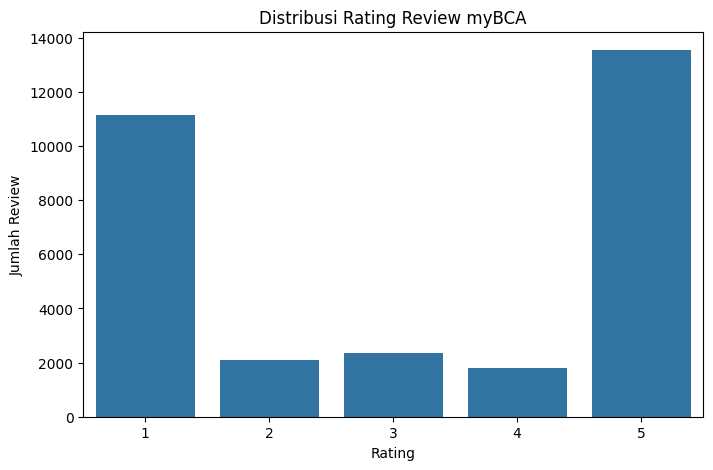

Persentase Rating (%):
-> Menghitung panjang review berdasarkan token...


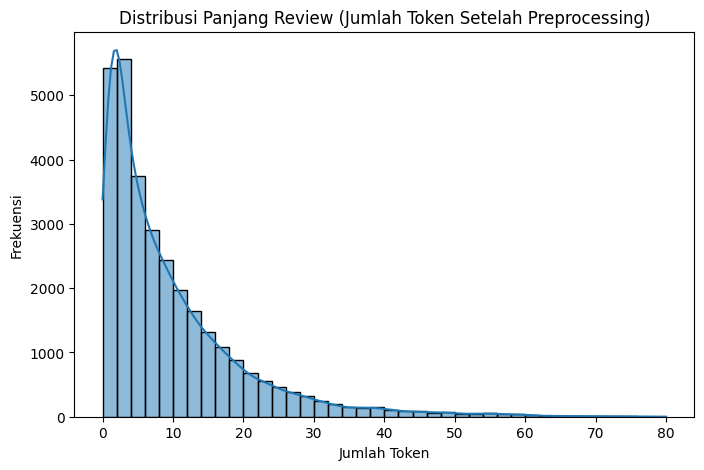

Rata-rata panjang review: 9.38 token


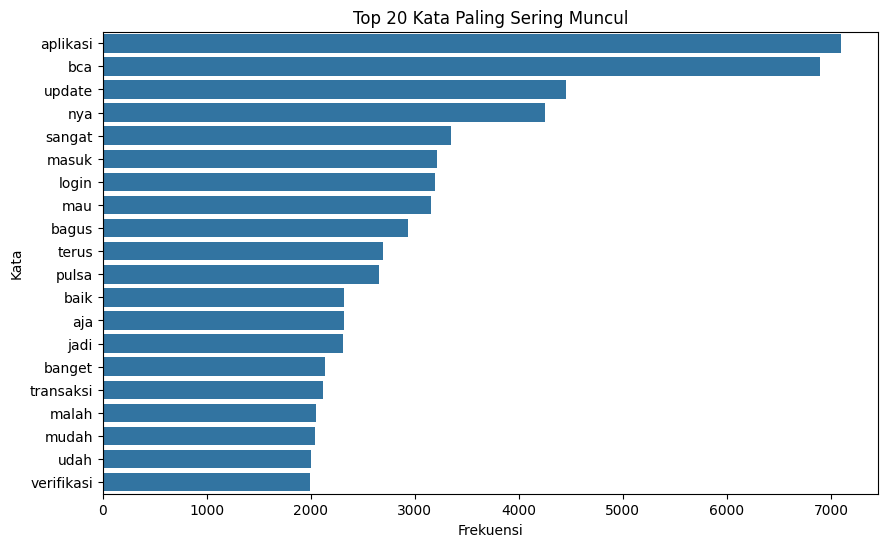

,Kata,Frekuensi
0,aplikasi,7095
1,bca,6893
2,update,4452
3,nya,4251
4,sangat,3350
5,masuk,3211
6,login,3189
7,mau,3152
8,bagus,2938
9,terus,2696


In [15]:
# Distribusi Rating Review
import matplotlib.pyplot as plt
import seaborn as sns

print("=== DISTRIBUSI RATING ===")

rating_counts = df_processed["score"].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values)

plt.title("Distribusi Rating Review myBCA")
plt.xlabel("Rating")
plt.ylabel("Jumlah Review")
plt.show()

rating_counts

# Persentase Rating
rating_percentage = (
    df_processed["score"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Persentase Rating (%):")
rating_percentage.round(2)

# Panjang Review (Text Length Analysis)
print("-> Menghitung panjang review berdasarkan token...")

df_processed["text_length"] = df_processed["tokens"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df_processed["text_length"], bins=40, kde=True)

plt.title("Distribusi Panjang Review (Jumlah Token Setelah Preprocessing)")
plt.xlabel("Jumlah Token")
plt.ylabel("Frekuensi")
plt.show()

print("Rata-rata panjang review:",
      round(df_processed["text_length"].mean(),2),
      "token")
# Top 20 Kata Paling Sering Muncul
from collections import Counter

all_words = [
    word
    for tokens in df_processed["tokens"]
    for word in tokens
]

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

top_20_df = pd.DataFrame(top_20, columns=["Kata", "Frekuensi"])

plt.figure(figsize=(10,6))
sns.barplot(data=top_20_df, x="Frekuensi", y="Kata")

plt.title("Top 20 Kata Paling Sering Muncul")
plt.xlabel("Frekuensi")
plt.ylabel("Kata")
plt.show()

top_20_df

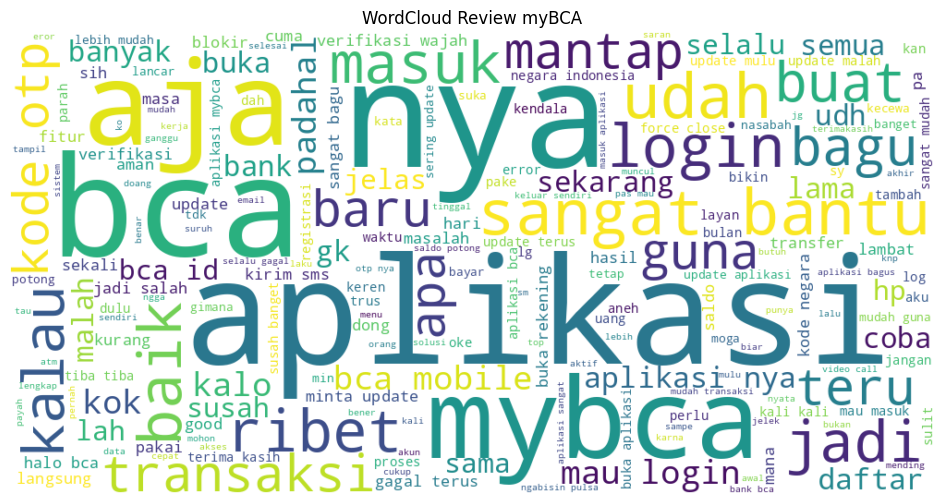

,Kata Negatif,Frekuensi
0,aplikasi,3919
1,bca,3299
2,nya,2189
3,login,2118
4,pulsa,2109
5,mau,1995
6,update,1936
7,masuk,1884
8,aja,1685
9,terus,1667


In [16]:
!pip install wordcloud

# WordCloud (Visual Insight Cepat)
from wordcloud import WordCloud

text_corpus = " ".join(all_words)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_corpus)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud Review myBCA")
plt.show()

# Analisis Kata Berdasarkan Rating (Optional Advanced Insight)
low_rating = df_processed[df_processed["score"] == 1]

low_words = [
    word
    for tokens in low_rating["tokens"]
    for word in tokens
]

low_freq = Counter(low_words).most_common(15)
pd.DataFrame(low_freq, columns=["Kata Negatif", "Frekuensi"])

In [19]:
!git clone https://github.com/Fachreza28/pba-task-1a-individual.git
%cd pba-task-1a-individual

Cloning into 'pba-task-1a-individual'...
/content/pba-task-1a-individual/pba-task-1a-individual/pba-task-1a-individual


In [31]:
!ls "/content/drive/MyDrive/Colab Notebooks"


'Homework 1 PBA.ipynb'	 pba-task-1a-individual.ipynb


In [32]:
!cp "/content/drive/MyDrive/Colab Notebooks/Tugas_Week1_PBA.ipynb" /content/pba-task-1a-individual/

cp: cannot stat '/content/drive/MyDrive/Colab Notebooks/Tugas_Week1_PBA.ipynb': No such file or directory


In [10]:
!git add .
!git commit -m "Tugas Week 1 PBA"
!git push

[main (root-commit) 9689712] Tugas Week 1 PBA
 1 file changed, 30968 insertions(+)
 create mode 100644 mybca_reviews_raw_sample.csv
fatal: could not read Password for 'https://hp_rpekH4cw0pyB15boqMGLNcAMTboQHm0kyfzO@github.com': No such device or address
